In [3]:
import numpy as np
import pandas as pd

from skimage import io
from scipy.stats import levene,f_oneway,kruskal,tukey_hsd

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ConfIntSampler

import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from tqdm import tqdm


In [5]:
masks = sorted(glob('/Users/reyesmatte/Desktop/copypasta/20260226/processed_masks/PY79*'))

dfs = []

for i in tqdm(range(len(masks))):

    m = masks[i]
    
    df = SizeDataFrame(maskfilelist=[m], from_files=True,pixsize=33.02/512)
    df = df[df['Width'] > 0.3]
    df = df[df['Length'] < 20]
    df.dropna()
    dfs.append(df)

 22%|███████████████████████████████████████████▎                                                                                                                                                            | 13/60 [00:02<00:09,  4.80it/s]/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 27%|█████████████████████████████████████████████████████▎                                                                                                                                                  | 16/60 [00:03<00:12,  3.51it/s]/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty s

In [6]:
### Define the sizes of sampling
sizes = np.arange(5,55,5)
idxs = np.arange(0,len(dfs),1)

In [13]:
sampled_df_w = pd.concat(ws,ignore_index=True)
sampled_df_w = sampled_df_w.dropna()
sampled_df_w.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS11_sampling_width.csv')

sampled_df_L = pd.concat(Ls,ignore_index=True)
sampled_df_L = sampled_df_L.dropna()
sampled_df_L.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS11_sampling_length.csv')


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 44.69it/s]


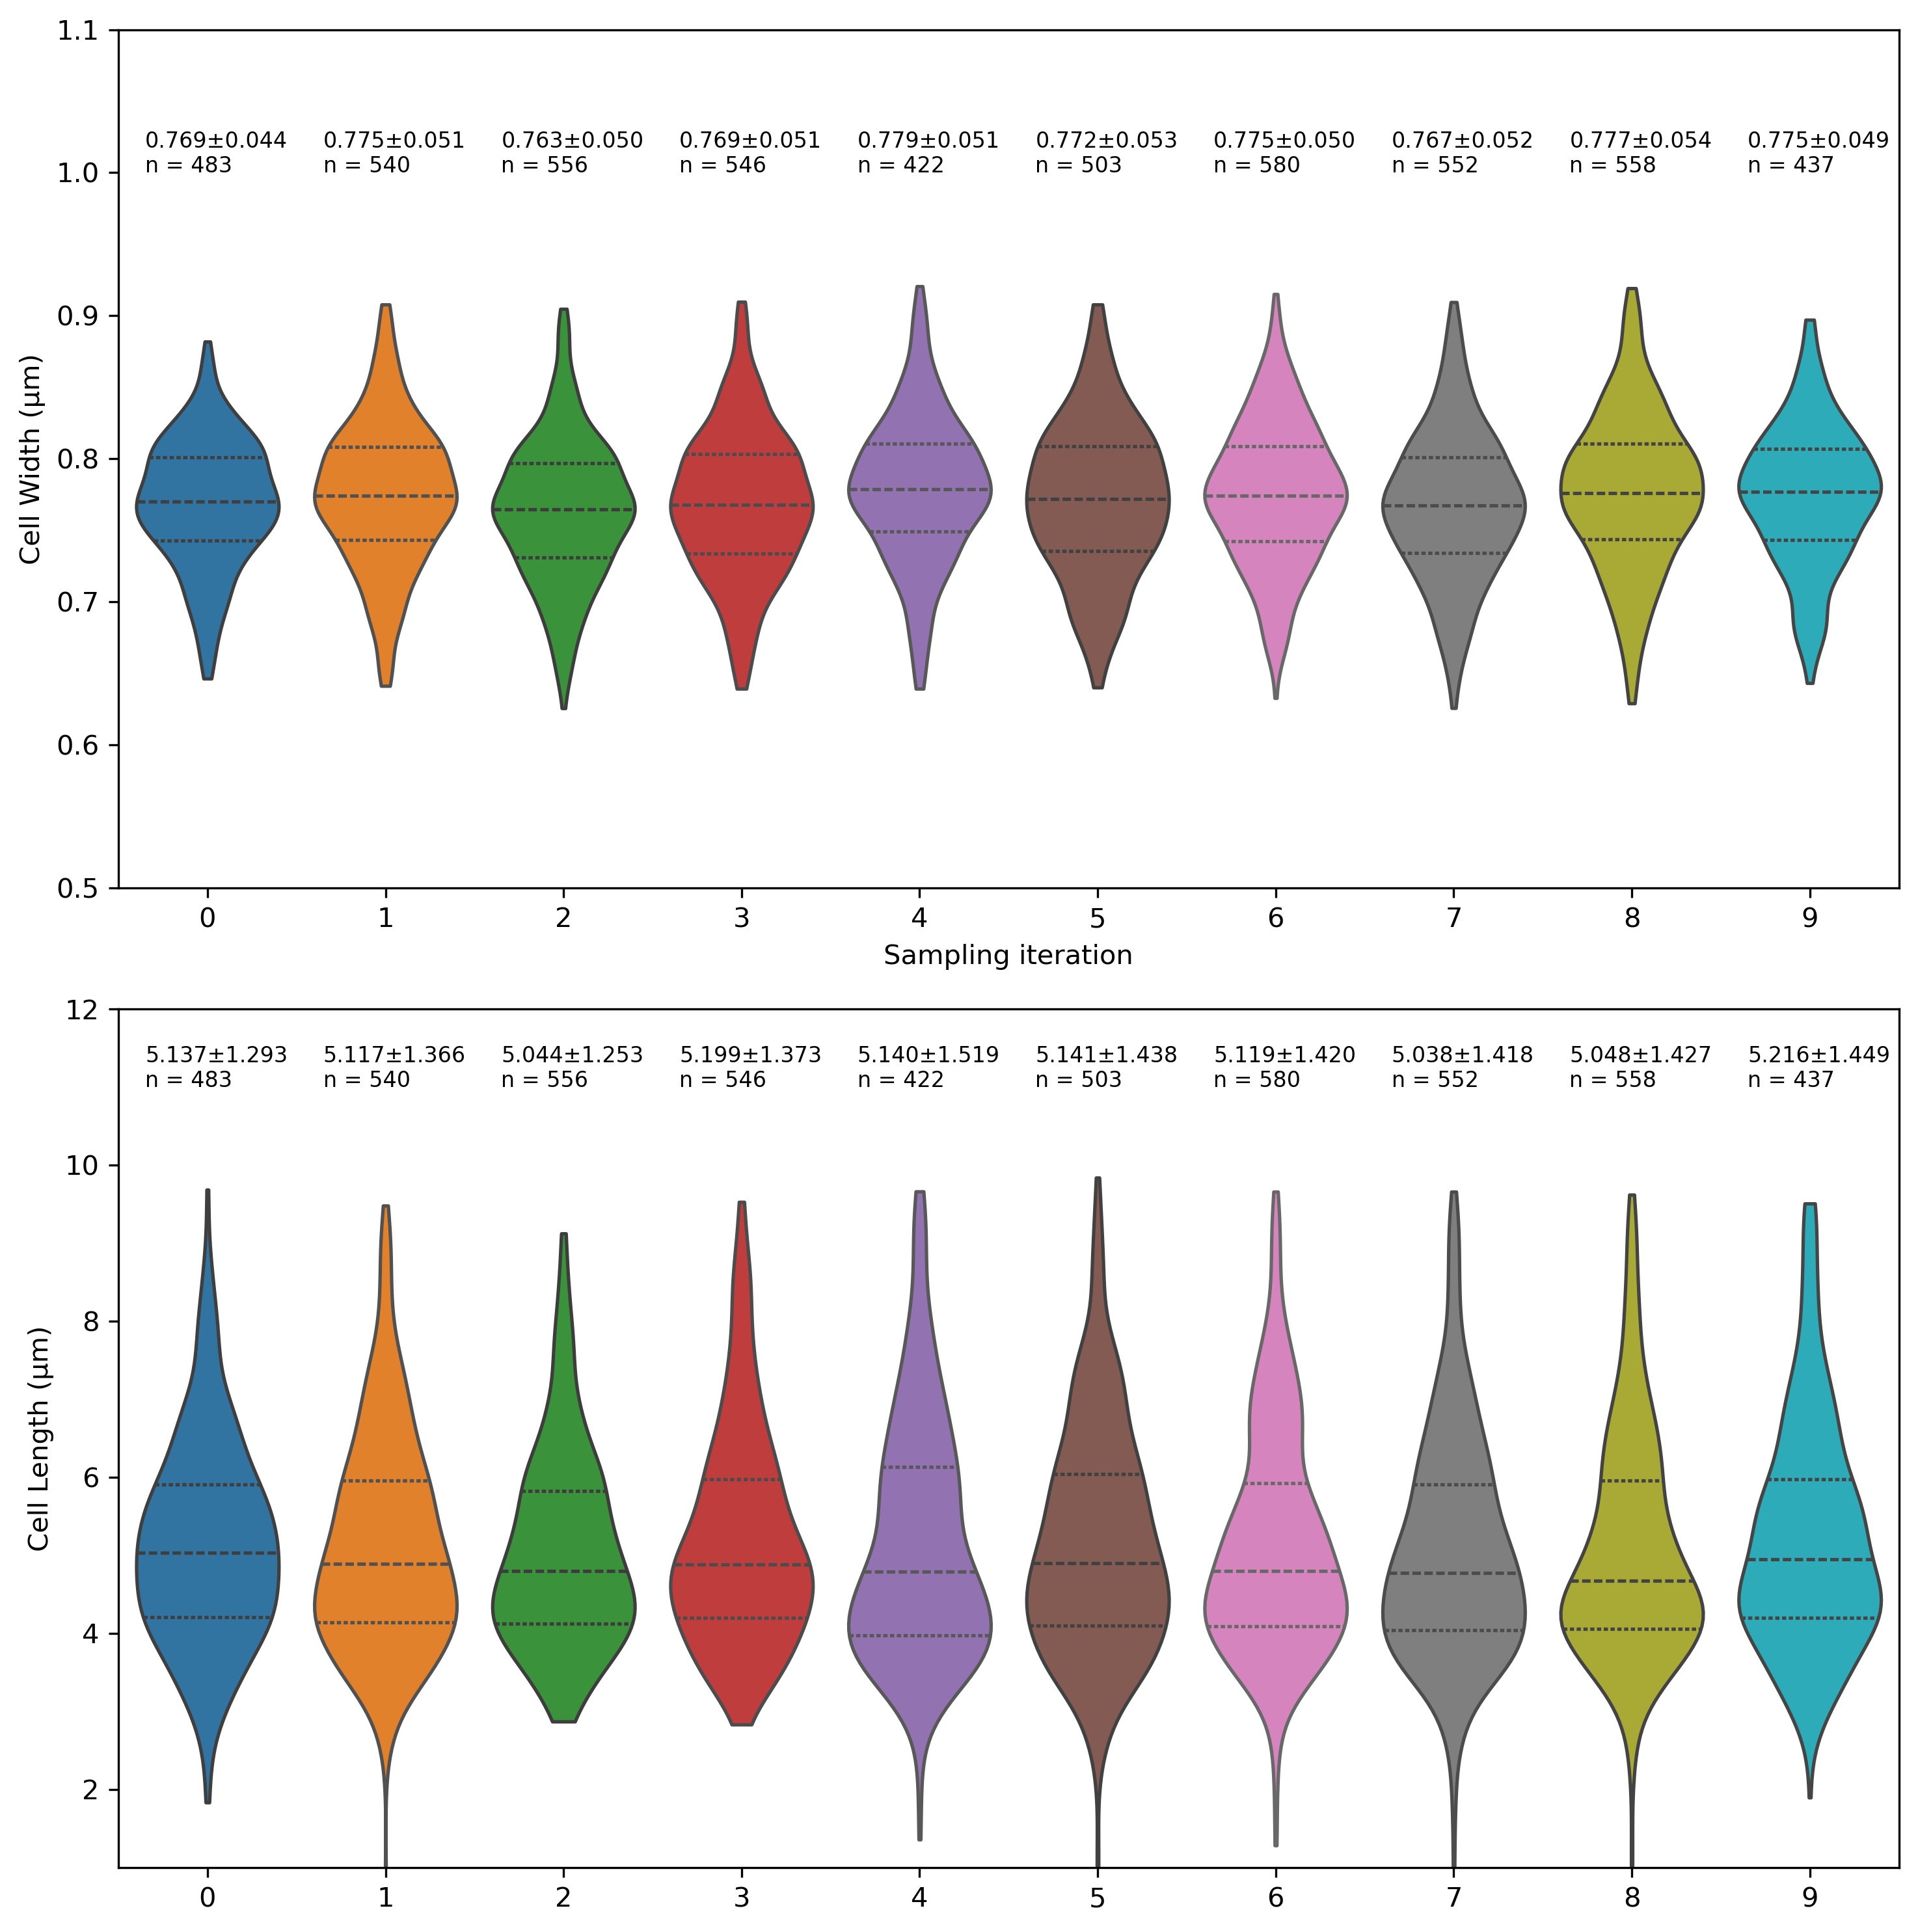

In [16]:
fig,ax = plt.subplots(dpi=300,figsize=(10,10),nrows=2)

kept_dfs_w = []
kept_dfs_L = []

seeds = np.arange(1,11,1)

for i in tqdm(range(10)):
    
    s_f1_cpsam = []
    s_f1_fmseg = []

    np.random.seed(seeds[i])
    selected = np.random.choice(idxs,10,replace=False,)

    selected_dfs = [dfs[s] for s in selected]
    
    selected_dfs = pd.concat(selected_dfs,ignore_index=True)
    selected_dfs.insert(0,'Sampling iteration',i)

    w = ConfIntSampler(df=selected_dfs,columns=['Sampling iteration'],metric='Width')
    L = ConfIntSampler(df=selected_dfs,columns=['Sampling iteration'],metric='Length')

    kept_dfs_w.append(w)
    kept_dfs_L.append(L)
    
    w = np.array(w['Width'])
    L = np.array(L['Length'])

    n = len(w)
    mu_w,sigma_w = np.nanmean(w),np.nanstd(w)
    mu_L,sigma_L = np.nanmean(L),np.nanstd(L)
  
    sns.violinplot(x=i,y=w,inner='quart',cut=0,ax=ax[0])
    sns.violinplot(x=i,y=L,inner='quart',cut=0,ax=ax[1])
    
    ax[0].text(i-0.35, 1, f'{mu_w:.3f}±{sigma_w:.3f}\nn = {n}',fontsize=8)
    ax[1].text(i-0.35, 11, f'{mu_L:.3f}±{sigma_L:.3f}\nn = {n}',fontsize=8)


ax[0].set_ylim(0.5,1.1)
ax[0].set_xlabel('Sampling iteration')
ax[0].set_ylabel('Cell Width (µm)')

ax[1].set_ylim(1,12)
ax[0].set_xlabel('Sampling iteration')
ax[1].set_ylabel('Cell Length (µm)')

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS11/Fig_SegmentationSampling_iterations.png')

In [19]:
###  Build the raw data table for plots

final_w = pd.concat(kept_dfs_w, ignore_index=True)
final_L = pd.concat(kept_dfs_L, ignore_index=True)

final_w.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS11_sampling_width.csv')
final_L.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS11_sampling_length.csv')

In [25]:
### And read it from GitHub
final_w = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS11_sampling_width.csv')
final_L = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS11_sampling_length.csv')

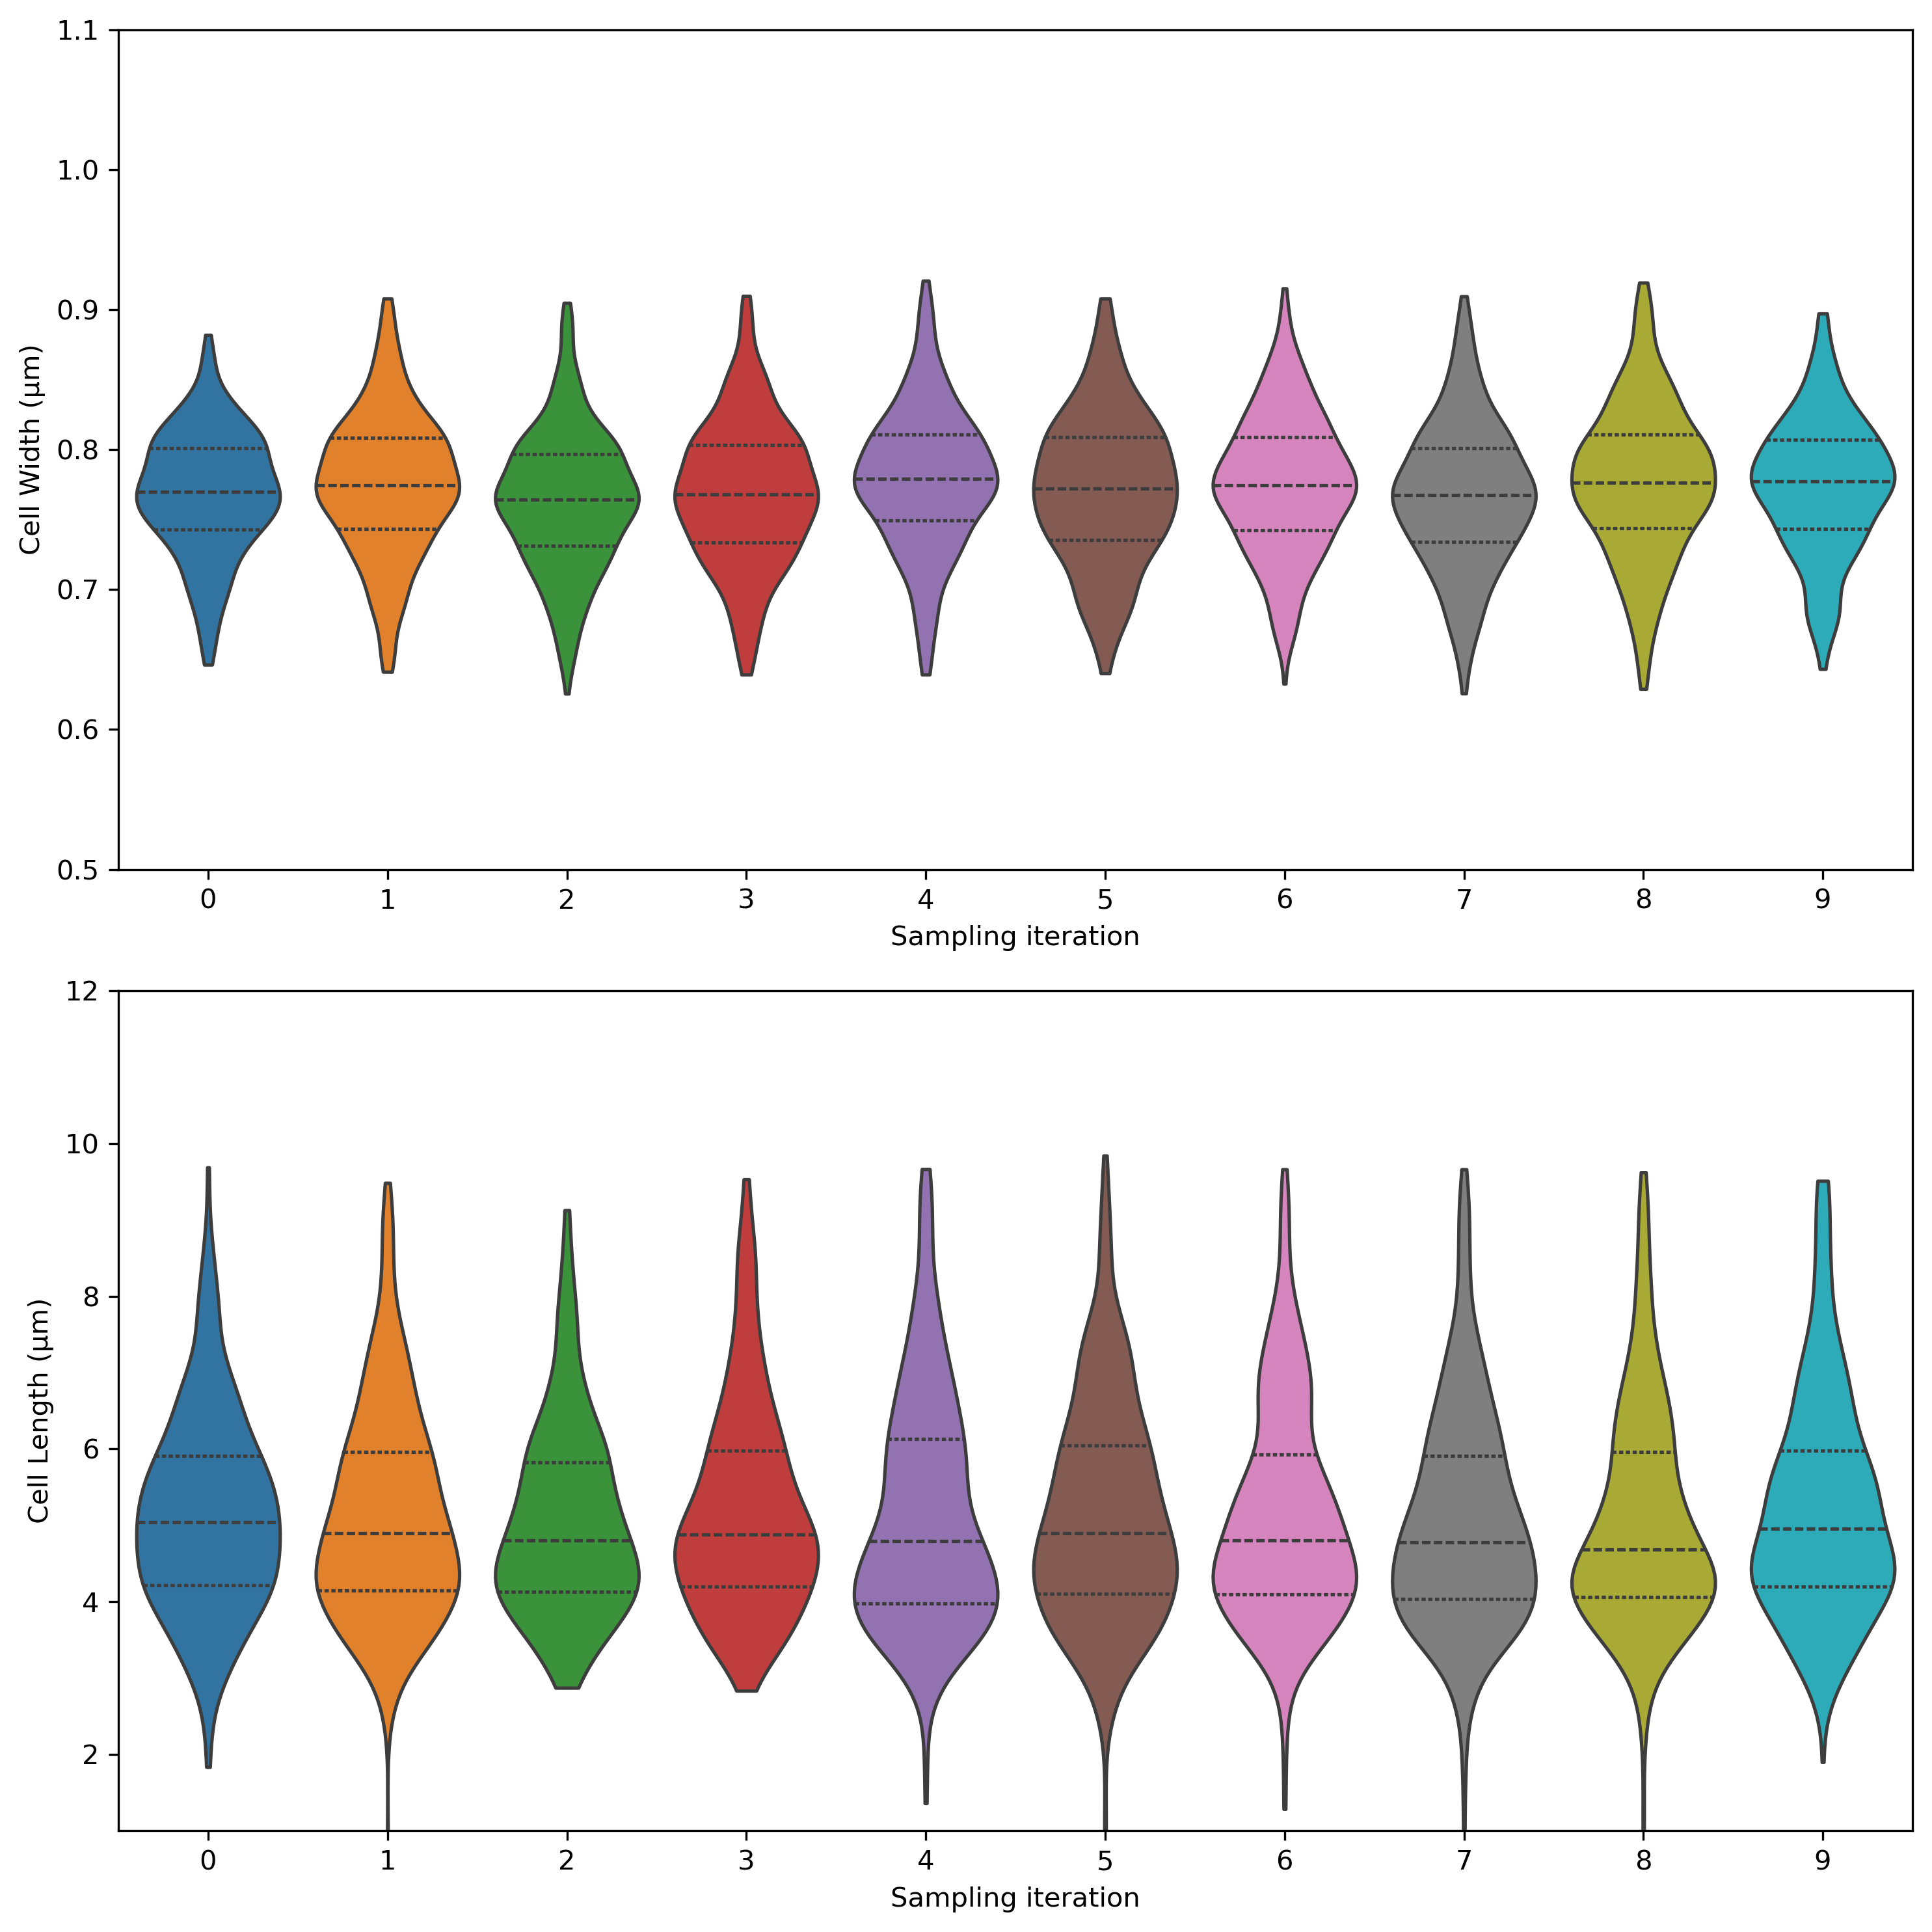

In [26]:
### Re-plot the violins
fig,ax = plt.subplots(dpi=300,figsize=(10,10),nrows=2)

sns.violinplot(data=final_w,x='Sampling iteration',y='Width',inner='quart',cut=0,ax=ax[0],hue='Sampling iteration',legend=False,palette=sns.color_palette('tab10'))
sns.violinplot(data=final_L,x='Sampling iteration',y='Length',inner='quart',cut=0,ax=ax[1],hue='Sampling iteration',legend=False,palette=sns.color_palette('tab10'))

ax[0].set_ylim(0.5,1.1)
ax[0].set_xlabel('Sampling iteration')
ax[0].set_ylabel('Cell Width (µm)')

ax[1].set_ylim(1,12)
ax[0].set_xlabel('Sampling iteration')
ax[1].set_ylabel('Cell Length (µm)')

fig.tight_layout()